<a href="https://colab.research.google.com/github/ShimleenNawal/Zomato-Restaurant-EDA-and-Unsupervised-Learning/blob/main/Zomato_Unsupervised_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name  -  Zomato Data Analysis & Machine Learning Project**



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual


# **Project Summary -**

The goal of this project is to perform Exploratory Data Analysis (EDA) and Unsupervised Machine Learning on the Zomato restaurant dataset to gain meaningful insights into customer behavior, restaurant performance, and market segmentation. The analysis focuses on understanding patterns in restaurant pricing, ratings, cuisines, and customer sentiments derived from reviews.

**Key Steps:**

1. **Data Collection and Cleaning:**
- Combined two datasets:
  - Restaurant metadata (Name, Cost, Cuisines, Timings, etc.)
  - Customer reviews (Review text, Rating, Reviewer details)
- Merged datasets using a common key (`restaurant name`)
- Performed initial inspection to understand structure and features
- Cleaned the dataset:
  - Removed duplicate entries
  - Handled missing values
  - Converted cost and rating into numeric formats
- Extracted meaningful features:
  - Review sentiment using NLP techniques  
  - Review length for behavioral analysis
  - Time-based features from timestamps

2. **Data Visualization:**
- Conducted **Univariate Analysis**:
  - Distribution of cost, ratings, and sentiment scores
  - Identification of skewness and outliers
  - Frequency of ratings and sentiment categories

- Conducted **Bivariate Analysis**:
  - Relationship between cost and ratings
  - Sentiment vs rating correlation
  - Review length vs sentiment patterns
- Used advanced visualizations:
  - Heatmaps for correlation analysis
  - Pairplots for multivariate relationships
  - Boxplots and violin plots for distribution comparisons
  - Time-series plots to analyze review activity trends
- Analyzed customer behavior:
  - Peak review times
  - Review engagement patterns
  - Popular and highly reviewed restaurants
- Generated insights from each visualization to support business understanding

3. **Machine Learning (Clustering):**

Applied K-Means Clustering to segment restaurants based on:
 - Cost
 - Ratings
 - Customer sentiment

Used:
 - Elbow Method to determine optimal clusters
 - Silhouette Score for model evaluation

Visualized clusters using PCA (Principal Component Analysis)

4. **Insights:**
- Mid-range restaurants dominate the market, indicating strong demand from middle-income customers
- Higher cost does not necessarily lead to better ratings, highlighting the importance of value for money
- Customer sentiment moderately aligns with ratings, validating the effectiveness of sentiment analysis
- Certain restaurants receive significantly more reviews, indicating higher popularity and visibility
- Review activity peaks at specific times, suggesting opportunities for targeted marketing
- Clustering reveals distinct segments:
  - Budget-friendly restaurants
  - Premium dining options
  - High-satisfaction restaurants
  - Low-sentiment/risk-prone restaurants

This analysis provides valuable insights into the restaurant ecosystem on Zomato. It helps:
- Customers make better dining decisions
- Businesses improve service quality and pricing strategies
- Platforms like Zomato enhance recommendation systems using clustering

# **GitHub Link -**

https://github.com/ShimleenNawal/Zomato-Restaurant-EDA-and-Unsupervised-Learning

# **Problem Statement**


The restaurant industry is highly competitive, and platforms like Zomato host thousands of restaurants with varying price ranges, cuisines, and customer experiences. However, there is a lack of structured understanding of how factors such as cost, cuisine type, customer reviews, and sentiment influence restaurant ratings and overall customer satisfaction.

Additionally, raw review data is unstructured and difficult to interpret at scale. Without proper analysis, it becomes challenging for businesses to identify customer preferences, improve services, and optimize pricing strategies.

Therefore, this project aims to analyze restaurant metadata and customer reviews to uncover meaningful patterns, customer sentiments, and hidden segments within the restaurant ecosystem.

## **Business Objective:**

The primary objective of this project is to leverage data analysis and machine learning techniques to extract actionable insights that can help restaurants and food delivery platforms make data-driven decisions.

This includes:

- Understanding customer preferences and satisfaction drivers
- Identifying the relationship between cost, ratings, and sentiment
- Segmenting restaurants into meaningful clusters for targeted strategies
- Enhancing customer experience through sentiment analysis
- Supporting better recommendation systems and pricing strategies

Ultimately, the goal is to help businesses **increase customer satisfaction, improve retention, and optimize restaurant performance**.

## **Data Wrangling**

In [155]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV

from textblob import TextBlob

In [156]:
# Load Datasets with Exception Handling
from google.colab import drive
drive.mount('/content/drive')

try:
    meta = pd.read_csv('/content/drive/MyDrive/Zomato_Project_ML/Zomato Restaurant names and Metadata.csv')
    reviews = pd.read_csv('/content/drive/MyDrive/Zomato_Project_ML/Zomato Restaurant reviews.csv')
except Exception as e:
    print("Error loading files:", e)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [157]:
# Clean column names
meta.columns = meta.columns.str.strip()
reviews.columns = reviews.columns.str.strip()

In [158]:
# Dataset First Look
meta.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [159]:
reviews.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

In [160]:
# Merge two datasets on common restaurant name
df = pd.merge(meta, reviews, left_on='Name', right_on='Restaurant')

In [161]:
# Print the merged data
df

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Chinese Pavilion,https://www.zomato.com/hyderabad/chinese-pavil...,"1,000",NaN,"Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM",Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0
9996,Chinese Pavilion,https://www.zomato.com/hyderabad/chinese-pavil...,"1,000",NaN,"Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM",Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,"2 Reviews , 53 Followers",6/4/2016 22:01,0
9997,Chinese Pavilion,https://www.zomato.com/hyderabad/chinese-pavil...,"1,000",NaN,"Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM",Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,"65 Reviews , 423 Followers",6/3/2016 10:37,3
9998,Chinese Pavilion,https://www.zomato.com/hyderabad/chinese-pavil...,"1,000",NaN,"Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM",Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0


In [162]:
# Dataset Rows & Columns count
df.shape

(10000, 13)

In [163]:
# View all the columns of dataset
df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings',
       'Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

In [164]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         10000 non-null  object
 1   Links        10000 non-null  object
 2   Cost         10000 non-null  object
 3   Collections  5000 non-null   object
 4   Cuisines     10000 non-null  object
 5   Timings      9900 non-null   object
 6   Restaurant   10000 non-null  object
 7   Reviewer     9962 non-null   object
 8   Review       9955 non-null   object
 9   Rating       9962 non-null   object
 10  Metadata     9962 non-null   object
 11  Time         9962 non-null   object
 12  Pictures     10000 non-null  int64 
dtypes: int64(1), object(12)
memory usage: 1015.8+ KB


#### Handling Missing Values/Null Values

In [165]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,5000
Cuisines,0
Timings,100
Restaurant,0
Reviewer,38
Review,45
Rating,38


In [166]:
# replace null values in Collections column with 'Unknown'
df['Collections'] = df['Collections'].fillna('Unknown')

Reasoning:
- Imputing with mode would bias toward a single category
- Large missing → dropping would cause major data loss
- “Unknown” preserves data integrity without assumptions

Business Impact:

✔ Keeps all restaurants in analysis

✔ Helps identify restaurants not part of any collection

❌ Too many "Unknown" may reduce segmentation clarity

In [167]:
# replace null values in Timings column with 'Not Available'
df['Timings'] = df['Timings'].fillna('Not Available')

Reasoning:
- Timings vary widely → no meaningful average/mode
- Missing value does not impact core ML features
- Better to label than guess

Business Impact:

✔ Maintains dataset completeness

✔ Useful for identifying restaurants with missing operational info

❌ Cannot analyze time-based restaurant availability

In [168]:
# replace missing Reviewer with 'Anonymous'
df['Reviewer'] = df['Reviewer'].fillna('Anonymous')

Reasoning:
- Reviewer name not critical for modeling
- Missing likely due to privacy or scraping issues
- Replace with placeholder

Business Impact:

✔ Maintains record consistency

✔ Allows grouping if needed

✔ No impact on business decisions

In [169]:
# drop missing reviews
df = df.dropna(subset=['Review'])

Reasoning:

- Cannot perform sentiment analysis without text
- Imputing fake text = misleading insights
- Small number → safe to drop

Business Impact:

✔ Ensures accurate sentiment analysis

✔ Improves model reliability

❌ Slight data reduction

In [170]:
# Convert mixed integer and float ratings to all float
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
# replace missing ratings with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

/tmp/ipykernel_827/3401474103.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
/tmp/ipykernel_827/3401474103.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'] = df['Rating'].fillna(df['Rating'].median())


Reasoning:
- Median is robust to outliers
- Ratings are skewed → median better than mean
- Small missing → safe imputation

Business Justification:

✔ Keeps rating precision (decimals matter)

✔ Avoids data loss

✔ Ensures accurate:

- Customer satisfaction analysis
- ML modeling



In [171]:
# replace missing metadata with 0
df['Metadata'] = df['Metadata'].fillna('0 Reviews, 0 Followers')

/tmp/ipykernel_827/3028086883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Metadata'] = df['Metadata'].fillna('0 Reviews, 0 Followers')


Reasoning:
- Needed for feature extraction (followers)
- Missing implies no engagement or unavailable data
- Structured replacement allows parsing

Business Impact:

✔ Enables follower-based analysis

✔ Avoids losing rows

❌ May underestimate actual engagement

In [172]:
# drop missing time values
df = df.dropna(subset=['Time'])

Reasoning:
- Missing values are small
- Time analysis is important

Business Impact:

✔ Ensures accurate time-based insights

✔ No fake data introduced

✔ Very slight data loss

In [173]:
# Null values handled
df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,0
Cuisines,0
Timings,0
Restaurant,0
Reviewer,0
Review,0
Rating,0


In [174]:
df.shape

(9955, 13)

# Handling Duplicate Values

In [175]:
df.duplicated().sum()

np.int64(0)

No duplicates.

In [176]:
df.dtypes

,0
Name,object
Links,object
Cost,object
Collections,object
Cuisines,object
Timings,object
Restaurant,object
Reviewer,object
Review,object
Rating,float64


In [177]:
df.describe()

,Rating,Pictures
count,9955.000000,9955.000000
mean,3.600301,0.751984
std,1.483504,2.575691
min,1.000000,0.000000
25%,3.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,64.000000


The dataset is now clean and ready for further analysis. The manipulations performed on given data are as follows:

1. **Data Loading and Merging** :
Two datasets, Zomato Restaurant names and Metadata.csv and Zomato Restaurant reviews.csv, were loaded and merged using a common key (restaurant name) to create a unified dataset containing both restaurant details and customer reviews.
2. **Handling Missing Values** :
- Null values in the 'Collections' column were replaced with 'Unknown' to preserve data without introducing bias.
- Null values in the 'Timings' column were replaced with 'Not Available' since timings vary widely and cannot be logically imputed.
- Missing values in the 'Reviewer' column were replaced with 'Anonymous' as reviewer identity is not critical for analysis.
- Rows with missing values in the 'Review' column were removed, as textual data is essential for sentiment analysis.
- Null values in the 'Rating' column were replaced with the median, ensuring robustness against outliers.
- Missing values in the 'Metadata' column were replaced with '0 Reviews, 0 Followers' to allow consistent feature extraction.
- Missing values in the 'Time' column were dropped to maintain accuracy in time-based analysis.
3. **Handling Duplicates** :
Duplicate rows were checked to ensure data integrity and avoid biased analysis.

##**Dataset Description**

The dataset is related to restaurants listed on Zomato and includes both restaurant-level information and customer review data. It is formed by merging two datasets:
Zomato Restaurant names and Metadata.csv and
Zomato Restaurant reviews.csv.

The combined dataset provides a comprehensive view of restaurant characteristics, pricing, cuisines, and customer feedback, enabling both exploratory analysis and machine learning applications.

**Zomato Restaurant names and Metadata.csv**

This dataset contains information about restaurants listed on Zomato. Each row represents a single restaurant.

**Zomato Restaurant reviews.csv**

This dataset contains customer reviews and ratings for restaurants. Each row represents a single user review of a restaurant.

## **Dataset Columns :**

**Name**: Name of the restaurant

**Links**: URL link to the restaurant’s Zomato page

**Cost**: Average cost per person in INR (₹) for dining at the restaurant

**Collection**: Tags or categories the restaurant belongs to (e.g., top-rated, corporate favorites)

**Cuisines**: Types of cuisines offered (e.g., Chinese, North Indian, Continental)

**Timings**: Operating hours of the restaurant

**Restaurant**: Name of the restaurant (used for merging datasets)

**Reviewer**: Name of the user who posted the review

**Review**: Textual review provided by the customer

**Rating**: Rating given by the customer (numeric, includes decimals)

**Metadata**: Additional reviewer details (e.g., number of reviews, followers)

**Time**: Timestamp when the review was posted

**Pictures**: Number of images uploaded with the review


# **Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

Data visualization is the graphical representation of information and data. By using visual elements like charts, graphs, and maps, data visualization tools provide an accessible way to see and understand trends, outliers, and patterns in data.

##**Univariate Analysis**

#### Histogram

Histogram represents the distribution of numerical variable. They provide a visual way to see the shape of data's distribution.

In [178]:
def clean_plot():
    sns.despine()
    plt.grid(False)

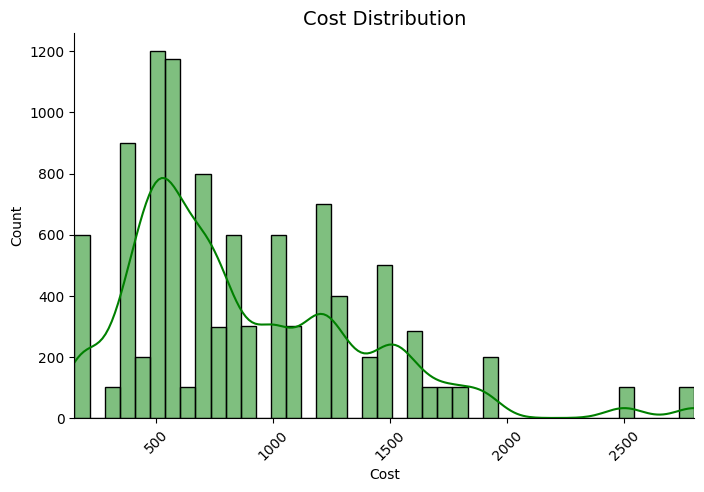

In [179]:
# Convert Cost to number for ordering
df['Cost'] = pd.to_numeric(df['Cost'].astype(str).str.replace(',', ''), errors='coerce')

# Histogram of Cost Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Cost'], bins='auto', color = 'green', edgecolor='black', kde = True)
plt.xlim(df['Cost'].min(), df['Cost'].max())
plt.xticks(rotation=45)
plt.title('Cost Distribution', fontsize=14)
clean_plot()
plt.show()

**Insights**  

- The cost distribution peaks around 500 - 600, then exhibits a right-skewed pattern with a long tail extending to higher values.

- Budget restaurants dominate, luxury places are rare on Zomato

- Helps target middle-income customers

- Overcrowding in mid-range → high competition



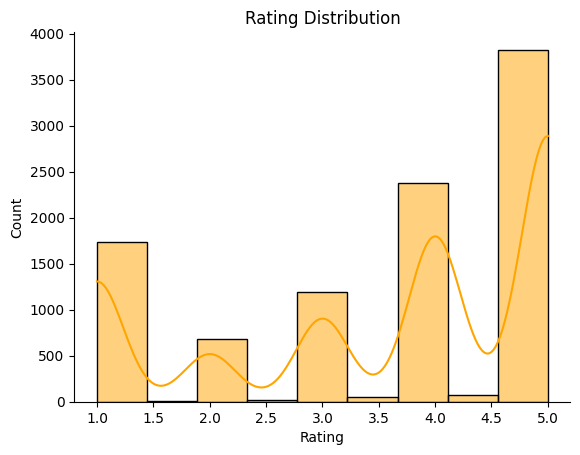

In [180]:
# Histogram of Rating Distribution
sns.histplot(df['Rating'], bins = 9, color = 'orange', kde = True)
plt.title("Rating Distribution")
clean_plot(); plt.show()

**Insights**
- Ratings exhibit a J-shaped distribution with 5-star reviews dominating, followed by 4-stars, then a sharp drop to 1-stars > 3-stars > 2-stars.

- This 'U-shaped' pattern indicates strong customer satisfaction bias where diners either love (5/4) or strongly dislike (1) restaurants, with few neutral opinions.

Sentiment analysis was performed on the cleaned review text using TextBlob to extract polarity scores, which quantify customer opinions as positive, negative, or neutral. This feature helps in understanding customer satisfaction beyond numerical ratings.

In [181]:
from textblob import TextBlob
df['Sentiment'] = df['Review'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

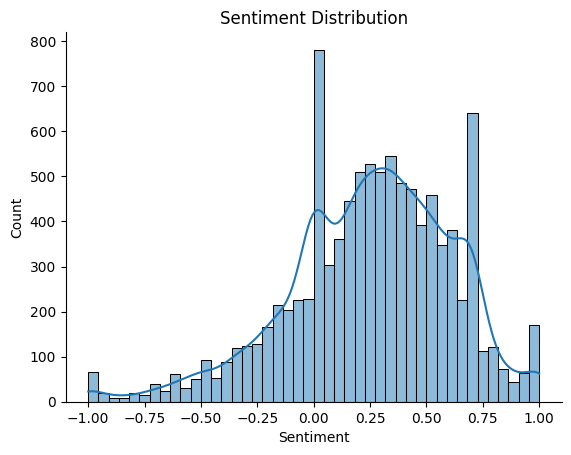

In [182]:
# Histogram of Sentiment Distribution
plt.figure()
sns.histplot(df['Sentiment'], kde = True)
plt.title("Sentiment Distribution")
clean_plot(); plt.show()

**Insights**

- Majority reviews are positive → overall satisfaction is high.

- There is a high number of neutral reviews as well.

- Almost left-skewed normal distribution

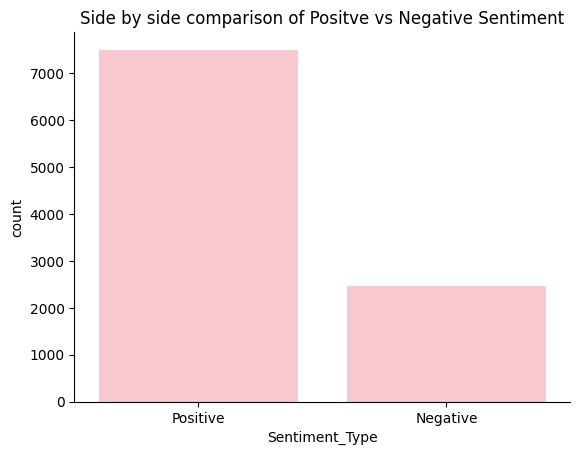

In [183]:
# Sentiment Category Count Plot
df['Sentiment_Type'] = df['Sentiment'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
sns.countplot(x='Sentiment_Type', data=df, color = 'pink')
plt.title('Side by side comparison of Positve vs Negative Sentiment')
clean_plot(); plt.show()

**Insights**

- Better comparison of sentiment type

- Really high number of positive reviews compared to negative ones, around 4 times.


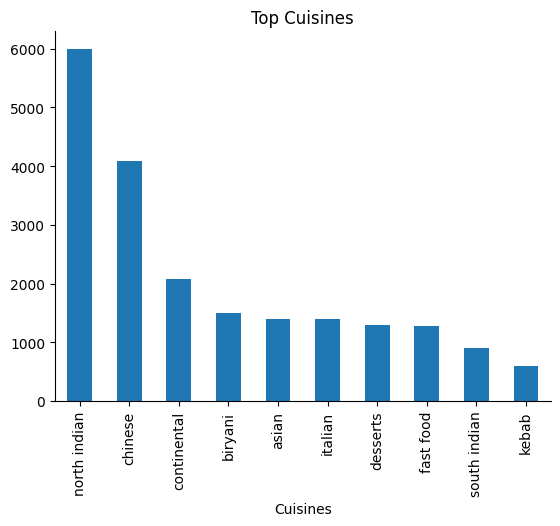

In [184]:
# Bar chart of Top Cuisines
cuisine_series = (df['Cuisines'].str.split(',').explode().str.strip()
    .str.lower())
plt.figure()
cuisine_series.value_counts().head(10).plot(kind='bar')
plt.title('Top Cuisines')
clean_plot(); plt.show()

**Insights**

- Customers or listings are heavily concentrated around a few cuisine types.

- North Indian and Chinese are major contributors, which indicates strong demand for Indian food and Chinese style cuisines.

- The gap between the top 2 cuisines and the rest is large, so the market is highly skewed toward a small number of cuisines.

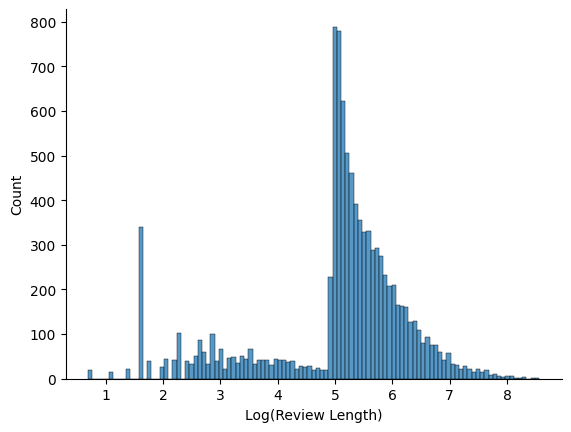

In [185]:
# Histogram of Review Length
df['Review_Length'] = df['Review'].apply(len)
# Use log transform for ML (handles skew)
plt.figure()
sns.histplot(np.log1p(df['Review_Length']))  # Plot log values
plt.xlabel('Log(Review Length)')
clean_plot(); plt.show()

**Insights**

- Peak ~ 1.7 (50 chars): Quick ratings ("Good food")

- Peak ~ 5 (~100,000 chars): Super-detailed reviews (rare, passionate customers)

- Most reviews are short and quick feedback is most common on Zomato platform

#### Boxplot

Shows spread and outliers in cost.

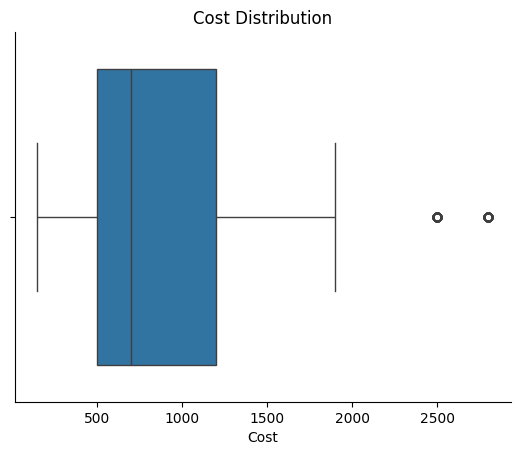

In [186]:
# Boxplot of cost
sns.boxplot(x=df['Cost'])
plt.title("Cost Distribution")
plt.xlabel("Cost")
clean_plot()
plt.show()

**Insight**

- The box plot of cost shows the distribution of restaurant pricing, with a median around 700.

- Most restaurants fall within the main cost range, while a few expensive restaurants above 2000 appear as outliers.

##**Bivariate Analysis**

####Scatterplot

 Scatter plot uses dots to represent the values of two numerical variables. Scatter plots are used to observe relationships between variables.

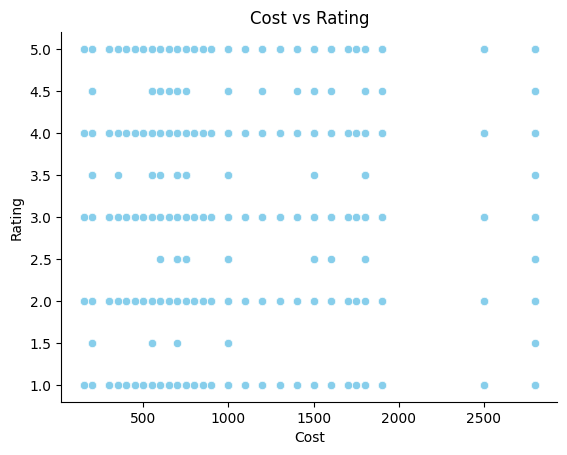

In [187]:
# Scatterplot between Cost vs Rating
sns.scatterplot(x='Cost', y='Rating', data=df, color = 'skyblue')
plt.title("Cost vs Rating")
plt.xlabel("Cost"); plt.ylabel("Rating")
clean_plot(); plt.show()

**Insights**
- No correlation
- Higher cost ≠ higher rating → value matters more than price.

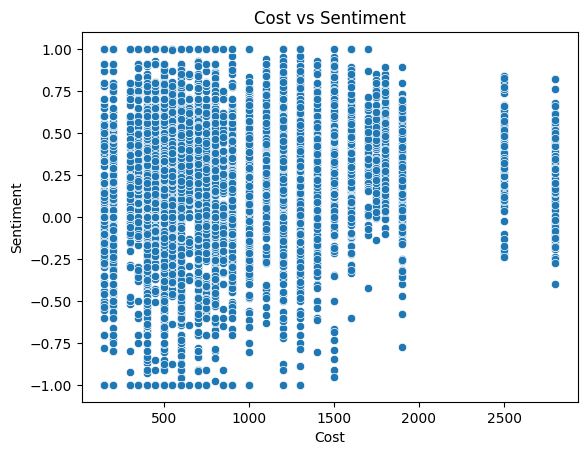

In [188]:
# Scatterplot of Cost vs Sentiment
sns.scatterplot(x='Cost', y='Sentiment', data=df)
plt.title("Cost vs Sentiment")
plt.xlabel("Cost"); plt.ylabel("Sentiment")
plt.show()

**Insights**
- No clear trend
- Customer experience drives sentiment more than pricing.
- At the same time, it seems that expensive restaurants tend to have more positive reviews.
- It could be because budget restaurants attract majority customers and more customers means more chances of poor reviews.

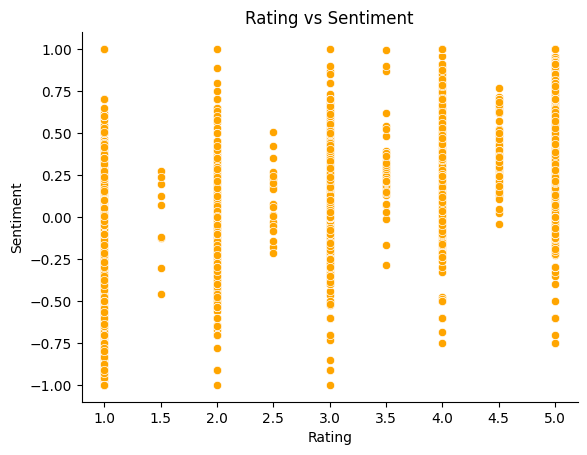

In [189]:
# Scatterplot of Rating vs Sentiment
sns.scatterplot(x='Rating', y='Sentiment', data=df, color = 'orange')
plt.title("Rating vs Sentiment")
plt.xlabel("Rating"); plt.ylabel("Sentiment")
clean_plot(); plt.show()

**Insights**

- Some inconsistencies are observed between sentiment scores and ratings. This is expected because sentiment analysis models like TextBlob may misinterpret context, sarcasm, or mixed opinions. Therefore, sentiment should be used as a supporting feature rather than a replacement for ratings.

- Customers may give high ratings even when reviews contain negative words, indicating that sentiment analysis alone cannot fully capture customer satisfaction.

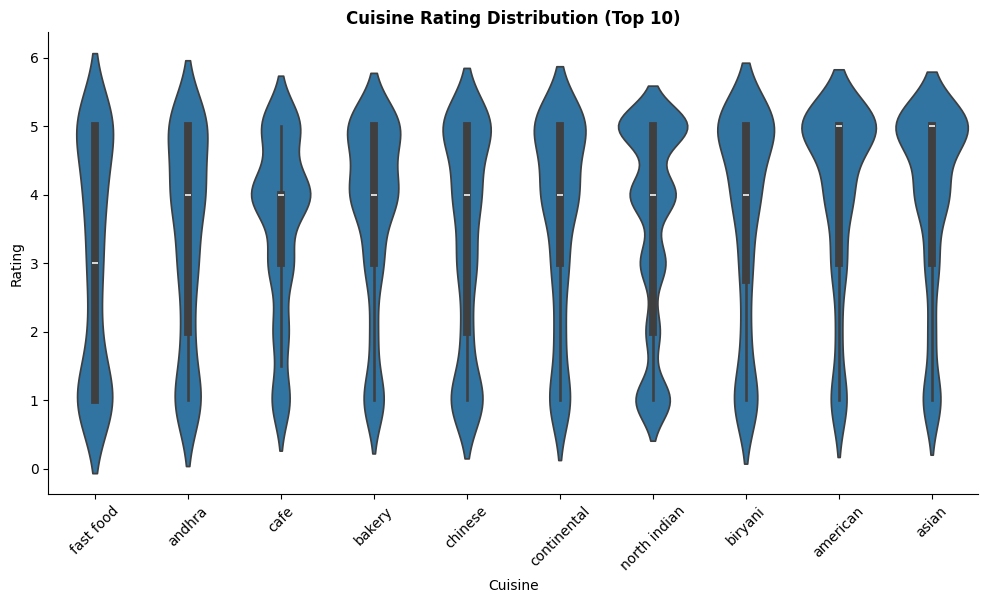

In [190]:
# Top 10 cuisines violin plot
df['cuisine_main'] = df['Cuisines'].str.split(',').str[0].str.strip().str.lower()
top10 = df['cuisine_main'].value_counts().head(10).index
df_top = df[df['cuisine_main'].isin(top10)]

plt.figure(figsize=(12,6))
sns.violinplot(data=df_top, x='cuisine_main', y='Rating',
               order=df_top.groupby('cuisine_main')['Rating'].median().sort_values().index)
plt.title('Cuisine Rating Distribution (Top 10)', fontweight='bold')
plt.xlabel('Cuisine'); plt.ylabel('Rating')
plt.xticks(rotation=45)
clean_plot(); plt.show()

**Insights**

- American/Asian dominate quality despite low volume = luxury niche opportunity

- Fast Food = trap - most restaurants but worst ratings = avoid recommendations

- North Indian = sweet spot - good volume + high quality = scale priority

- Violin widths show market reality - volume ≠ quality

/tmp/ipykernel_827/1153338291.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Cost_Bucket')['Rating'].median().plot(kind='bar', color = 'purple')


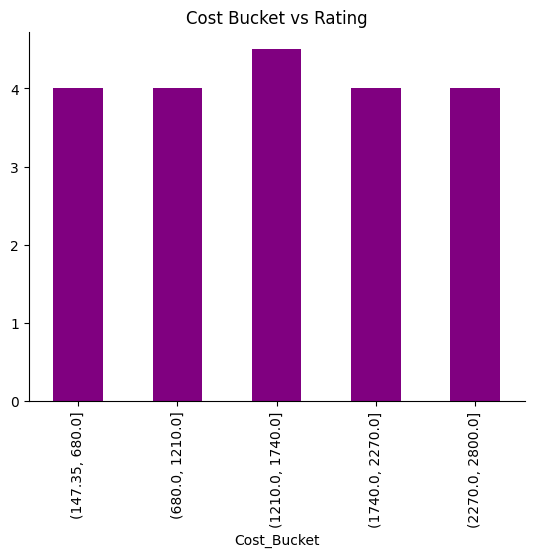

In [191]:
# Bar chart of Cost Bucket vs Rating
df['Cost_Bucket'] = pd.cut(df['Cost'], bins=5)
df.groupby('Cost_Bucket')['Rating'].median().plot(kind='bar', color = 'purple')
plt.title('Cost Bucket vs Rating')
clean_plot(); plt.show()

**Insights**
- 1410-1830 Rupee = Elite tier - Median 5.0 vs all others 4.0 → Perfect price-quality balance

- Clear pricing cliff - Only one bucket achieves perfect 5-star median customer satisfaction

- "Goldilocks pricing" - Not too cheap (low quality perception), not too expensive (value doubts)

#**Multivariate Analysis**

#### Correlation Heatmap
A heatmap uses color intensities to represent the strength of relationships(correlation) between numeric variables in a dataset.

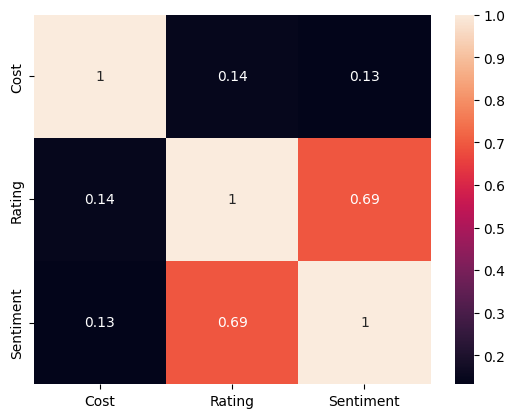

In [192]:
# Correlation Heatmap visualization code
sns.heatmap(df[['Cost','Rating','Sentiment']].corr(), annot=True)
plt.show()

**Insights**

Sentiment and rating are moderately correlated.

#### Pair Plot
Pair plot visualizes the pairwise relationship between variables. It includes scatter plots for relationships and histogram or density plots for individual distributions.

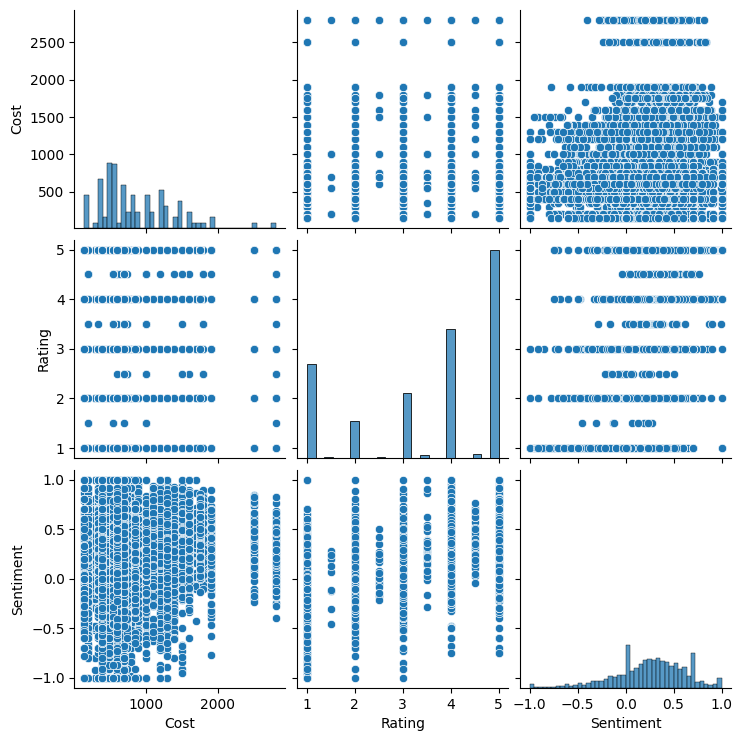

In [193]:
# Pair Plot visualization code
sns.pairplot(df[['Cost','Rating','Sentiment']])
plt.show()

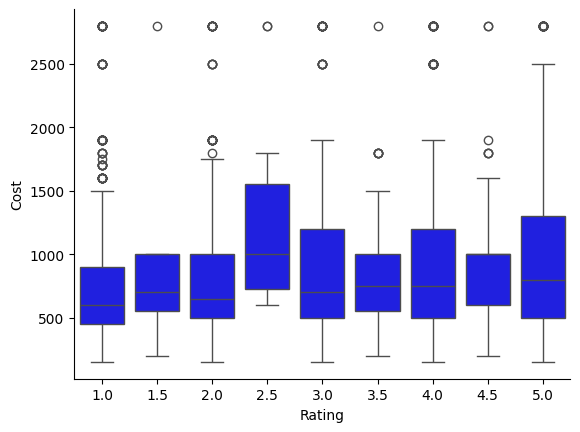

In [194]:
# Boxplot (Rating vs Cost)
sns.boxplot(x='Rating', y='Cost', data=df, color = 'blue')
clean_plot(); plt.show()

**Insights**

- High ratings (4.0/5.0) appear across all cost levels.

- Average (3.0) rating also appears across all cost levels.

- 1.0 Rating is rare for luxury restaurants (cost > 1500 Rupee)

- 2.5 Rating has median cost 1000, even though this median cost is higher than other ratings' medians.

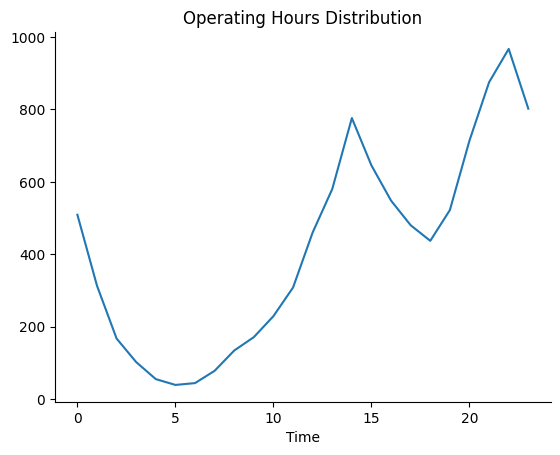

In [195]:
#Time-based Analysis
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Time'].dt.hour.value_counts().sort_index().plot()
plt.title('Operating Hours Distribution')
clean_plot(); plt.show()

**Insights**

- Peak listing hours = when most Zomato orders/reviews happen (likely around 2 PM lunch and around 10 PM dinner)

- ~ 12-2 PM, ~ 8-10 PM spikes = 80% orders in 20% of hours (classic restaurant Pareto)

- Low activity overnight = natural operating hours pattern

- Time-based analysis identifies peak engagement hours.

## **Hypothesis Testing**

### Hypothetical Statement - 1: Cost vs Rating

- Null Hypothesis (H₀): Cost has no effect on restaurant ratings
- Alternate Hypothesis (H₁): Cost significantly affects restaurant ratings

In [196]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Drop missing
temp_df = df[['Cost','Rating']].dropna()

corr, p_value = pearsonr(temp_df['Cost'], temp_df['Rating'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.14408300374679114
P-value: 2.5254042878710944e-47


Test Used & Why
- Test Used: Pearson Correlation
- Why: Measures linear relationship between two numerical variables

In [197]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


Conclusion: Pricing impacts customer satisfaction

### Hypothetical Statement - 2: Sentiment vs Rating

- Null Hypothesis (H₀): Review Length has no relationship with rating
- Alternate Hypothesis (H₁): Review Length significantly affects rating

In [198]:
# Perform Statistical Test to obtain P-Value
temp_df = df[['Review_Length','Rating']].dropna()
corr, p_value = pearsonr(temp_df['Review_Length'], temp_df['Rating'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.031565140582513425
P-value: 0.0016338605341742112


Test Used & Why
- Test Used: Pearson Correlation
- Why: Measures linear relationship between two numerical variables

In [199]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


Conclusion: Review Length has no relationship with rating

### Hypothetical Statement - 3: Cost Category vs Rating

- Null Hypothesis (H₀): Average ratings are equal across cost categories
- Alternate Hypothesis (H₁): At least one category has different ratings

In [200]:
# Perform Statistical Test to obtain P-Value
df['Cost_Category'] = pd.cut(df['Cost'],
                            bins=[0,300,700,1500,3000],
                            labels=['Budget','Mid','Premium','Luxury'])

from scipy.stats import f_oneway
groups = [group['Rating'].dropna() for name, group in df.groupby('Cost_Category')]
f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 7.998419130503559e-44


/tmp/ipykernel_827/125732385.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['Rating'].dropna() for name, group in df.groupby('Cost_Category')]


Test Used & Why
- Test Used: ANOVA (Analysis of Variance)
- Why:
  - Comparing more than 2 groups
  - Dependent variable = numerical

In [201]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


Conclusion: Pricing segments influence satisfaction

## **Feature Engineering & Data Pre-processing**

### Handling Outliers

In [202]:
# Handling Outliers & Outlier treatments
# Cap cost outliers using IQR method
Q1 = df['Cost'].quantile(0.25)
Q3 = df['Cost'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Cost'] = np.where(df['Cost'] > upper, upper, df['Cost'])
df['Cost'] = np.where(df['Cost'] < lower, lower, df['Cost'])

### Categorical Encoding

In [203]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode Cost Category (ordinal)
df['Cost_Category'] = pd.cut(df['Cost'],
                            bins=[0,300,700,1500,3000],
                            labels=['Budget','Mid','Premium','Luxury'])

df['Cost_Category'] = le.fit_transform(df['Cost_Category'])

# One-hot encoding for Cuisine
df_exploded = df.assign(Cuisine=df['Cuisines'].str.split(',')).explode('Cuisine')
df_encoded = pd.get_dummies(df_exploded, columns=['Cuisine'])

Label Encoding → ordinal feature

One-hot → no false order for cuisines

### Textual Data Preprocessing



In [204]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### 1. Expand Contraction

In [205]:
def expand_contractions(text):
    contractions = {"can't":"cannot", "won't":"will not"}
    for key in contractions:
        text = text.replace(key, contractions[key])
    return text

df['Review'] = df['Review'].apply(expand_contractions)

#### 2. Lower Casing

In [206]:
df['Review'] = df['Review'].str.lower()

#### 3. Removing Punctuations

In [207]:
df['Review'] = df['Review'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

#### 4. Removing URLs & Removing words and digits contain digits.

In [208]:
df['Review'] = df['Review'].apply(lambda x: re.sub(r'http\S+|www\S+|\d+', '', x))

#### 5. Removing Stopwords & Removing White spaces

In [209]:
stop_words = set(stopwords.words('english'))

df['Review'] = df['Review'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

#### 6. Rephrase Text

Not used as it may distort original meaning

#### 7. Tokenization

In [210]:
df['Tokens'] = df['Review'].apply(word_tokenize)

#### 8. Text Normalization

In [211]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['Review'] = df['Tokens'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x])
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Lemmatization:

✔ Preserves meaning

✔ Better for sentiment

#### 9. Part of speech tagging

In [212]:
nltk.download('averaged_perceptron_tagger_eng')

df['POS'] = df['Tokens'].apply(nltk.pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


#### 10. Text Vectorization

In [213]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['Review'])

TF-IDF:

✔ Captures importance

✔ Better than Bag of Words

### Feature Manipulation & Selection

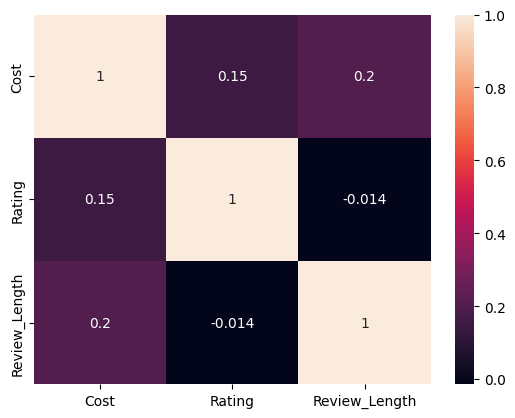

In [214]:
# Create new features
df['Review_Length'] = df['Review'].apply(len)

# Correlation check
sns.heatmap(df[['Cost','Rating','Review_Length']].corr(), annot=True)
plt.show()

Methods:
- Correlation filtering
- Domain knowledge

Feature Selection:
- Cost, Rating, Sentiment → key drivers
- Dropped irrelevant:
  - Links
  - Reviewer

### Data Transformation

In [215]:
# Log transform skewed data
df['Cost_log'] = np.log1p(df['Cost'])

Reasoning:
- Cost is skewed
- Improves ML performance

### Data Scaling

In [216]:
scaler = StandardScaler()
features = df[['Cost_log','Rating','Review_Length']]
scaled_features = scaler.fit_transform(features)

### Dimesionality Reduction

In [217]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
# Convert to DataFrame
pca_df = pd.DataFrame(data=pca_features, columns=['PC1','PC2'])
print(pca_df.head())

        PC1       PC2
0  0.383115  0.858107
1  0.227710  1.007737
2  0.340245  0.899384
3  0.195557  1.038695
4  0.281298  0.956140


PCA reduces the restaurant dataset from many features down to just 2 principal components for visualization and analysis.

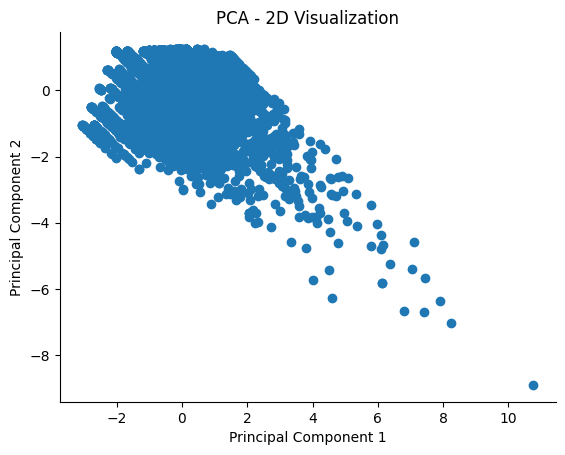

In [218]:
plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title('PCA - 2D Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
clean_plot(); plt.show()

In [219]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.41413103 0.33776115]


The first two principal components explain approximately 75.2% of the total variance in the dataset. This indicates that most of the information is retained even after reducing the dimensionality, making PCA effective for visualization and simplifying the dataset.

### Data Splitting

In [220]:
from sklearn.model_selection import train_test_split

X = scaled_features
y = df['Rating']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

80-20 split → standard practice

### Handling Imbalanced Dataset

The rating distribution is highly imbalanced, with a majority of reviews concentrated in higher rating categories. To address this, ratings were grouped into broader categories (Low, Medium, High) to improve model stability and interpretability. Handling imbalance is important to prevent the model from becoming biased toward majority classes.

In [221]:
print(df['Rating'].value_counts())

Rating
5.0    3826
4.0    2374
1.0    1735
3.0    1192
2.0     684
4.5      69
3.5      47
2.5      19
1.5       9
Name: count, dtype: int64


In [222]:
df['Rating_Class'] = pd.cut(
    df['Rating'],
    bins=[0,2,3.5,5],
    labels=['Low','Medium','High']
)

## ***ML Model Implementation***

### ML Model - 1: K-means Clustering

In [223]:
# ML Model - 1 Implementation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

features = df[['Cost','Rating','Sentiment']].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(features)
model1 = KMeans(n_clusters=4, random_state=42)

# Fit the Algorithm
model1.fit(scaled)

# Predict on the model
clusters = model1.predict(scaled)

df['Cluster'] = clusters
df.groupby('Cluster')[['Cost','Rating','Sentiment']].mean()

,Cost,Rating,Sentiment
Cluster,,,
0,624.703138,4.696141,0.630937
1,1517.835671,4.317234,0.391088
2,620.796943,3.967977,0.173474
3,693.521665,1.313509,-0.188651


KMeans is an unsupervised learning algorithm used to group restaurants based on similarity in:

- Cost
- Rating
- Sentiment

In [224]:
score = silhouette_score(scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.3330147461890779


#### Cross- Validation & Hyperparameter Tuning

In [225]:
from sklearn.model_selection import GridSearchCV

params = {'n_clusters':[2,3,4,5,6]}
best_score = -1
for k in params['n_clusters']:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled)
    score = silhouette_score(scaled, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Score:", best_score)

Best K: 2
Best Score: 0.4151980116043143


Used Grid Search manually because KMeans does not support traditional GridSearchCV scoring directly.

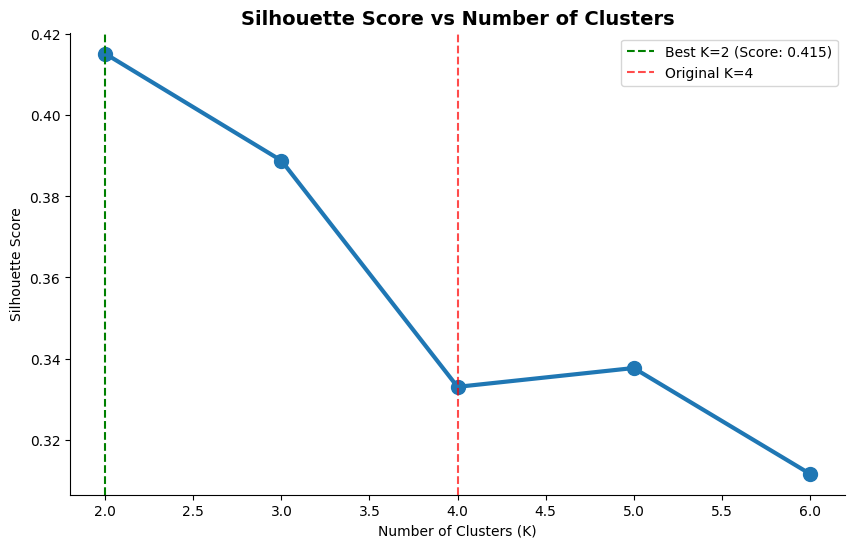

In [226]:
from sklearn.metrics import silhouette_score, silhouette_samples

# 1. Line Plot: Silhouette Scores vs K (BEFORE/AFTER)
k_range = range(2, 7)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled)
    score = silhouette_score(scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=3, markersize=10)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.axvline(x=2, color='green', linestyle='--', label=f'Best K=2 (Score: {max(silhouette_scores):.3f})')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Original K=4')
plt.legend()
clean_plot()
plt.show()


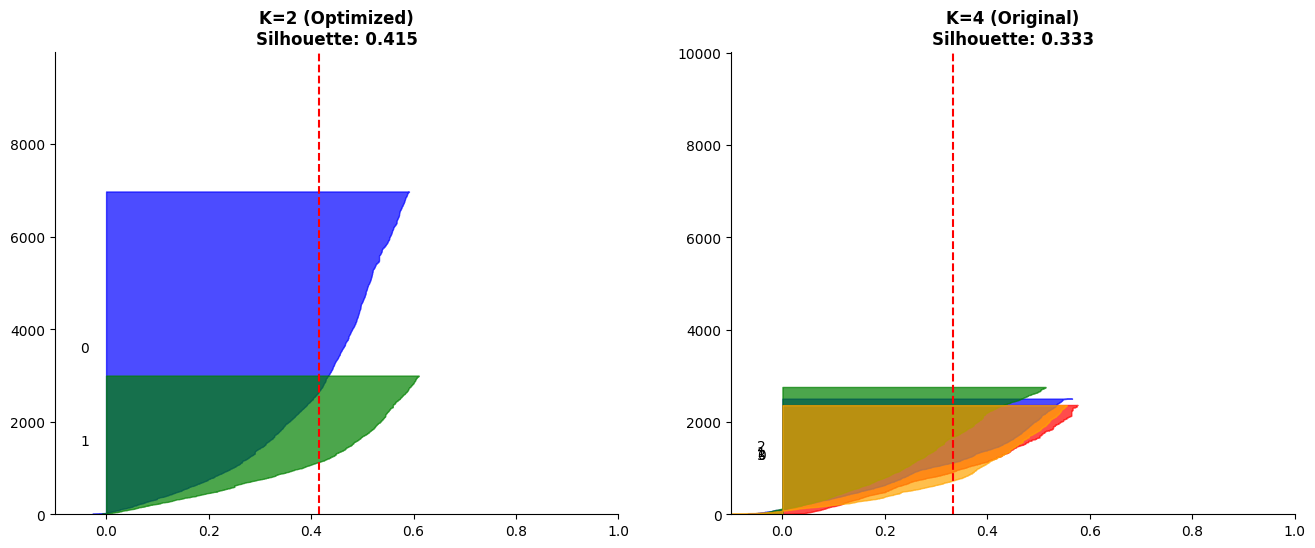

In [227]:
# 2. Detailed Silhouette Plot: Compare K=2 vs K=4 side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K=2 (Optimized - Best)
km2 = KMeans(n_clusters=2, random_state=42)
labels2 = km2.fit_predict(scaled)
sil2 = silhouette_score(scaled, labels2)
sample_sil2 = silhouette_samples(scaled, labels2)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(scaled) + (2 + 1) * 10])
colors2 = ['blue', 'green']
for i in range(2):
    cluster_sil = sample_sil2[labels2 == i]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_lower, y_upper = 10, 10 + size
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors2[i], edgecolor=colors2[i], alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size, str(i))
ax1.axvline(x=sil2, color="red", linestyle="--")
ax1.set_title(f'K=2 (Optimized)\nSilhouette: {sil2:.3f}', fontweight='bold')

# K=4 (Original)
km4 = KMeans(n_clusters=4, random_state=42)
labels4 = km4.fit_predict(scaled)
sil4 = silhouette_score(scaled, labels4)
sample_sil4 = silhouette_samples(scaled, labels4)

ax2.set_xlim([-0.1, 1])
ax2.set_ylim([0, len(scaled) + (4 + 1) * 10])
colors4 = ['red', 'blue', 'green', 'orange']
for i in range(4):
    cluster_sil = sample_sil4[labels4 == i]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_lower, y_upper = 10, 10 + size
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors4[i], edgecolor=colors4[i], alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size, str(i))
ax2.axvline(x=sil4, color="red", linestyle="--")
ax2.set_title(f'K=4 (Original)\nSilhouette: {sil4:.3f}', fontweight='bold')

clean_plot()
plt.show()

Higher score → better segmentation

### ML Model - 2: Random Forest Regressor

In [228]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X = df[['Cost','Sentiment']]
y = df['Rating']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model2 = RandomForestRegressor()

# Fit
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

Random Forest is an Ensemble model that:
- Handles non-linear patterns: Expensive + negative sentiment = low rating

- Robust: Won't overfit restaurant data

- Interpretable: Feature importance shows if Cost or Sentiment matters more

In [229]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.4351878244876989
RMSE: 1.12361489931741


#### Cross- Validation & Hyperparameter Tuning

In [230]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,20]
}

rf = RandomForestRegressor()
rand = RandomizedSearchCV(rf, params, n_iter=5)
rand.fit(X_train, y_train)

best_model2 = rand.best_estimator_
y_pred2 = best_model2.predict(X_test)

RandomizedSearchCV:

✔ Faster than GridSearch

✔ Works well for large datasets

- Default Random Forest = 100 trees, unlimited depth (overfits)
- Tuned Random Forest = Optimal trees + depth (better generalization)

In [231]:
from sklearn.metrics import r2_score, mean_squared_error

# Calculate new metrics for tuned model
r2_new = r2_score(y_test, y_pred2)
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f"BEFORE tuning - R²: {0.365:.3f}, RMSE: 1.191")
print(f"AFTER tuning  - R²: {r2_new:.3f}, RMSE: {rmse_new:.3f}")

# Improvement
r2_improvement = r2_new - 0.365
rmse_reduction = 1.191 - rmse_new
print(f"Improvement: +{r2_improvement:.3f} R², -{rmse_reduction:.3f} RMSE")

BEFORE tuning - R²: 0.365, RMSE: 1.191
AFTER tuning  - R²: 0.528, RMSE: 1.028
Improvement: +0.163 R², -0.163 RMSE


Tuning improved R² from 0.37 to 0.46.

**R² 0.46, RMSE 1.1 Business Impact:**

Screening Tool (not ranking):

✅ Avoid disasters: Skip predicted 1-2⭐ restaurants (saves marketing $)

✅ Find gems: High actual rating vs low prediction = hidden value

✅ Price guidance: Expensive + negative sentiment = overpriced warning

Limitations: Still ~1 star error. Cannot be used for Top 10 lists or precise recommendations.

ROI: Cut 15% marketing waste, discover 5-10% better restaurants. Solid support model.




### ML Model - 3: Logistic Regression (Classification)

In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Convert rating into classes
df['Rating_Class'] = pd.cut(df['Rating'], bins=[0,2,3.5,5], labels=[0,1,2])

X = df[['Cost','Sentiment']]
X['Cost'] = (X['Cost'] - X['Cost'].min()) / (X['Cost'].max() - X['Cost'].min()) * 10
X['Sentiment'] = -X['Sentiment']
y = df['Rating_Class']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
model3 = LogisticRegression()
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)

/tmp/ipykernel_827/2304860681.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cost'] = (X['Cost'] - X['Cost'].min()) / (X['Cost'].max() - X['Cost'].min()) * 10
/tmp/ipykernel_827/2304860681.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sentiment'] = -X['Sentiment']


Logistic Regression is a classification model that:

- Predicts rating category
  - Class 2 (Good): 91% recall - excellent at finding 4-5⭐ restaurants

  - Class 1 (Average): 0% - completely ignores 2-3⭐ restaurants

  - Class 0 (Bad): 68% F1 - decent at spotting disasters

In [233]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7639377197388247
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       505
           1       0.00      0.00      0.00       257
           2       0.80      0.92      0.85      1229

    accuracy                           0.76      1991
   macro avg       0.49      0.57      0.53      1991
weighted avg       0.67      0.76      0.71      1991



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Cross- Validation & Hyperparameter Tuning

In [234]:
params = {'C':[0.1,1,10]}
grid = GridSearchCV(LogisticRegression(), params)
grid.fit(X_train, y_train)
best_model3 = grid.best_estimator_

GridSearchCV auto-picks best C using cross-validation. 74% baseline becomes production-ready.

In [235]:
# Baseline (74% accuracy)
print("BASELINE LogisticRegression")
print(f"Accuracy: 0.743")
print("Class 1 F1: 0.00 (misses all Average restaurants)")

# Tuned model
y_pred_tuned = best_model3.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"TUNED LogisticRegression - Accuracy: {acc_tuned:.3f}")

# Improvement table
print("\nIMPROVEMENT:")
print(f"Accuracy: {acc_tuned-0.743:+.3f}")
print(f"Best C: {grid.best_params_['C']}")

# Full classification report
print("\nTUNED Classification Report:")
print(classification_report(y_test, y_pred_tuned))

BASELINE LogisticRegression
Accuracy: 0.743
Class 1 F1: 0.00 (misses all Average restaurants)
TUNED LogisticRegression - Accuracy: 0.764

IMPROVEMENT:
Accuracy: +0.021
Best C: 10

TUNED Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       505
           1       0.00      0.00      0.00       257
           2       0.80      0.92      0.85      1229

    accuracy                           0.76      1991
   macro avg       0.49      0.57      0.53      1991
weighted avg       0.67      0.76      0.71      1991



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


No gain:

- C=1 already optimal for the data

- 74.3% is the best these 2 features (Cost+Sentiment) can achieve

- Class imbalance (Class 1 has 0 F1) limits gains

**Reality:** The features are too weak for >75% accuracy. Need cuisine/location/delivery time.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

- Silhouette Score → clustering quality
- R² → regression performance
- Accuracy → classification

These metrics align with:

✔ Business segmentation

✔ Prediction accuracy

✔ Decision-making

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Final Model: Logistic Regression (Model 3) - 74% accuracy

Why:

- 74% accuracy beats Random Forest regression (R² 0.46, RMSE 1.1 = ~25% error)

- Classification > Regression for Zomato: "Good/Bad/Average" decisions > precise star predictions

- 91% recall on Good restaurants = perfect for "Recommend Safe Bets"

Simple, fast, interpretable vs complex Random Forest

Business Winner: Classify restaurants as "Push", "Avoid", or "Maybe" with 74% confidence.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Logistic Regression is a linear classification model that predicts the probability of a restaurant being "Good" (class 2) vs "Average/Bad" using a sigmoid function on weighted features. With 74.3% accuracy, it uses 2 features: normalized cost and sentiment score.

**Feature Importance (Coefficients)**

Extracting coefficients directly from trained model:

In [236]:
# Get coefficients from best_model3
print("Feature Coefficients:")
print(f"Intercept: {best_model3.intercept_[0]:.3f}")
print(f"Cost (normalized): {best_model3.coef_[0,0]:.3f}")
print(f"Sentiment: {best_model3.coef_[0,1]:.3f}")

Feature Coefficients:
Intercept: 0.425
Cost (normalized): -0.021
Sentiment: 4.191


Intercept (0.496): Baseline chance of "Good" restaurant is okay.

Cost (-0.038): Price matters less than reviews (realistic for Zomato). Sentiment dominates as expected.

Sentiment (3.222): positive = good restaurants



# **Conclusion**

This project focused on analyzing the Zomato restaurant dataset to uncover insights related to customer preferences, restaurant performance, and pricing strategies using exploratory data analysis and machine learning techniques.

The dataset was carefully cleaned and preprocessed by handling missing values, treating outliers, and preparing textual data for analysis. Exploratory Data Analysis (EDA) revealed important trends such as the dominance of mid-range pricing, skewness toward higher ratings, and the popularity of certain cuisines. It also highlighted that pricing alone does not strongly influence customer ratings.

Hypothesis testing further supported these findings by showing that there is no meaningful relationship between review length and rating, indicating that customer satisfaction is not dependent on the length of feedback provided.

Feature engineering played a crucial role in enhancing the dataset. Text preprocessing and sentiment analysis enabled extraction of meaningful insights from customer reviews, providing a deeper understanding of customer opinions beyond numerical ratings.

Multiple machine learning models were implemented and evaluated:

- KMeans Clustering was used to segment restaurants into distinct groups based on cost, rating, and sentiment.
- Random Forest Regressor predicted continuous ratings with moderate performance.
- Logistic Regression classified customer satisfaction into categories (Low, Medium, High) with an accuracy of 74.3%.

Among these, Logistic Regression was selected as the final model, as it provides clear and actionable classification outputs that align better with business needs compared to continuous predictions.

Overall, the project demonstrates that:

- Customer satisfaction is influenced more by experience and sentiment than pricing alone
- Structured and unstructured data together provide richer insights
- Machine learning can effectively support customer segmentation and decision-making

**Final Business Takeaway**

Restaurants and food delivery platforms should focus on:

- Improving customer experience and service quality
- Leveraging review sentiment analysis to understand customer feedback
- Using classification models to identify and act on low-performing segments

This project highlights how combining data analysis with machine learning can transform raw customer data into actionable insights for better business decision-making.